- Đọc raw corpus đã cho ở thư mục `data` và lưu các document trong corpus vào `list`

In [6]:
from collections import Counter
from lab2.ngram_lm import NGramLanguageModel
from sklearn.model_selection import train_test_split

import gzip
import json
import math
import matplotlib.pyplot as plt
import pandas as pd
import re

Experiment 1: Corpus statistics


- In ra một document bất kỳ và số lượng document sau khi đọc dữ liệu

In [8]:
data_path = '/Users/cuongtran/Downloads/c4-train.00000-of-01024-30K.json.gz'

# Tiền xử lý dữ liệu
raw_corpus = []

with gzip.open(data_path, 'rt', encoding = 'utf-8') as f:
    for line in f:
        data = json.loads(line)
        raw_corpus.append(data['text'])

print(f'Số document: {len(raw_corpus)}')

sentences_corpus_list = []

for document in raw_corpus:
    sentences_doc = re.split(r'[.!?\n]+', document)
    sentences_doc = [s.strip() for s in sentences_doc if s.strip()]
    sentences_corpus_list.append(sentences_doc)

print(f'Số câu: {sum(len(sen) for sen in sentences_corpus_list)}')

tokens_corpus = []
for sentences_doc in sentences_corpus_list:
    for sentence in sentences_doc:
        tokens = re.findall(r"[A-Za-z0-9]+(?:[-+'][A-Za-z0-9]+)*", sentence.lower())
        tokens_corpus.append(tokens)

print(f'Số token: {sum(len(token) for token in tokens_corpus)}')

vocabulary = sorted({token
                    for token_doc in tokens_corpus
                    for token in token_doc})
print(f'Kích thước vocabulary: {len(vocabulary)}')

# Đếm số lần xuất hiện cửa từng n-gram.
unigram_counter = Counter(
    token
    for sentence in tokens_corpus
    for token in sentence
)

bigram_counter = Counter(
    (sentence[i], sentence[i + 1])
    for sentence in tokens_corpus
    for i in range(len(sentence) - 1)
)

trigram_counter = Counter(
    (sentence[i], sentence[i + 1], sentence[i + 2])
    for sentence in tokens_corpus
    for i in range(len(sentence) - 2)
)

ngram_counters = {
    'Unigram': unigram_counter,
    'Bigram': bigram_counter,
    'Trigram': trigram_counter,
}
# Tổng hợp số n-gram khác nhau (unique n-grams) và số n-gram chỉ xuất hiện đúng một lần (singleton n-grams).
df = pd.DataFrame([
    {
        'Model': model,
        'Unique n-grams': len(counter),
        'Singleton n-grams': sum(count == 1 for count in counter.values()),
    }
    for model, counter in ngram_counters.items()
])

df

Số document: 30000
Số câu: 691345
Số token: 10944235
Kích thước vocabulary: 227775


,Model,Unique n-grams,Singleton n-grams
0,Unigram,227775,118823
1,Bigram,2798004,2023094
2,Trigram,6382988,5525227


- Xây dựng pipeline biểu diễn ma trận TF-IDF trên dataset

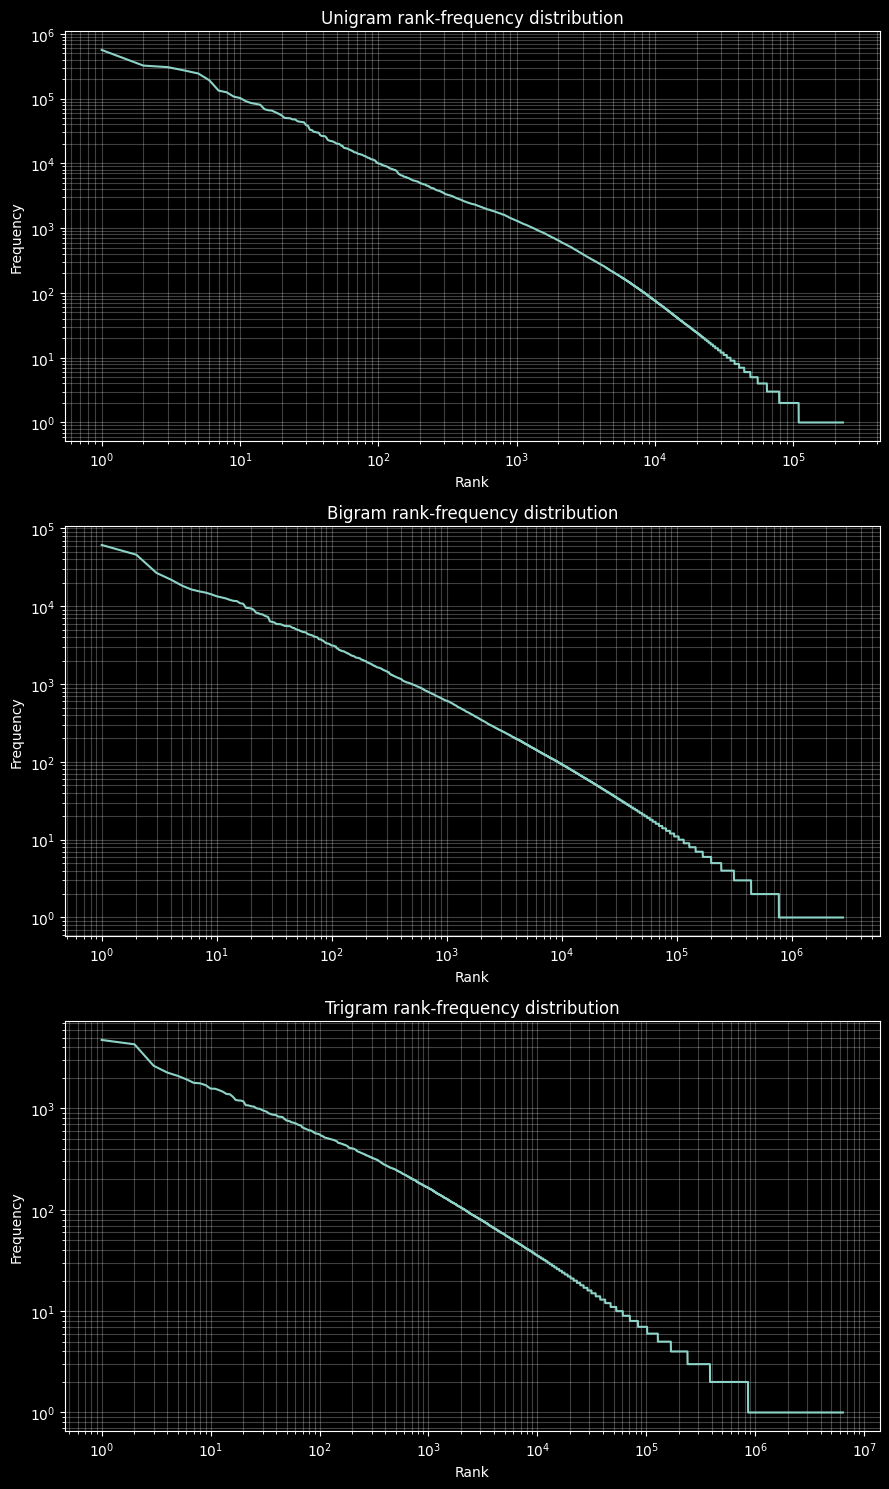

In [9]:
# Vẽ rank-frequency distribution trên thang log-log.
fig, axes = plt.subplots(3, 1, figsize=(9, 15))

for axis, (model, counter) in zip(axes, ngram_counters.items()):
    frequencies = sorted(counter.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)

    axis.loglog(ranks, frequencies)
    axis.set_title(f'{model} rank-frequency distribution')
    axis.set_xlabel('Rank')
    axis.set_ylabel('Frequency')
    axis.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()

Experiment 2: MLE vs Smoothing

In [10]:
## Chia corpus thành 3 phần: Train:80%, Validation:10%, Test:10%

train_corpus, temp_corpus = train_test_split(
    tokens_corpus,
    test_size = 0.2,
    random_state = 42
)

valid_corpus, test_corpus = train_test_split(
    temp_corpus,
    test_size = 0.5,
    random_state = 42
)

## Xử lý từ hiếm và OOV
# Đếm số token xuất hiện trong corpus huấn luyện
train_token_counts = Counter(
    token
    for sentence in train_corpus
    for token in sentence
)

# Lọc ra token xuất hiện ít nhất 2 lần rồi thêm vào từ điển
min_count = 2
train_vocabulary = {
    token
    for token, count in train_token_counts.items()
    if count >= min_count
}
# Thay từ hiếm trong train corpus hay từ chỉ xuất hiện trong validation/test bằng <UNK>
train_vocabulary.add('<UNK>')
def replace_oov(sentence, vocabulary):
    return [
        word if word in vocabulary else '<UNK>'
        for word in sentence
    ]

train_processed = [
    replace_oov(sentence, train_vocabulary)
    for sentence in train_corpus
]

valid_processed = [
    replace_oov(sentence, train_vocabulary)
    for sentence in valid_corpus
]

test_processed = [
    replace_oov(sentence, train_vocabulary)
    for sentence in test_corpus
]

print(f'Train sentences: {len(train_processed):,}')
print(f'Validation sentences: {len(valid_processed):,}')
print(f'Test sentences: {len(test_processed):,}')
print(f'Train vocabulary including <UNK>: {len(train_vocabulary):,}')

models = {
    'Bigram MLE': NGramLanguageModel(n=2, smoothing=False),
    'Bigram Laplace': NGramLanguageModel(n=2, smoothing=True),
    'Trigram MLE': NGramLanguageModel(n=3, smoothing=False),
    'Trigram Laplace': NGramLanguageModel(n=3, smoothing=True),
}
for model in models.values():
    model.fit(train_processed)

def corpus_perplexity(model, corpus):
    """Tính perplexity từ từng log-probability của tòan bộ corpus."""
    total_log_probability = 0.0
    total_tokens = 0

    for sentence in corpus:
        if not sentence:
            continue

        log_probability = model.sentence_log_probability(sentence)
        if log_probability == float('-inf'):
            return float('inf')

        total_log_probability += log_probability
        total_tokens += len(sentence)

    if total_tokens == 0:
        raise ValueError('Corpus must contain at least one token')

    return math.exp(-total_log_probability / total_tokens)


results = []
for model_name, model in models.items():
    results.append({
        'Model': model_name,
        'Train PPL': corpus_perplexity(model, train_processed),
        'Validation PPL': corpus_perplexity(model, valid_processed),
        'Test PPL': corpus_perplexity(model, test_processed),
    })
    experiment_2_results = pd.DataFrame(results)
    experiment_2_results

Train sentences: 553,076
Validation sentences: 69,134
Test sentences: 69,135
Train vocabulary including <UNK>: 96,506


Experiment 3: Perplexity

In [11]:
# Tao them hai mo hinh unigram. Bigram va trigram duoc tai su dung tu Experiment 2.
experiment_3_models = {
    'Unigram MLE': NGramLanguageModel(n=1, smoothing=False),
    'Unigram Laplace': NGramLanguageModel(n=1, smoothing=True),
    'Bigram MLE': models['Bigram MLE'],
    'Bigram Laplace': models['Bigram Laplace'],
    'Trigram MLE': models['Trigram MLE'],
    'Trigram Laplace': models['Trigram Laplace'],
}

for model_name in ('Unigram MLE', 'Unigram Laplace'):
    experiment_3_models[model_name].fit(train_processed)

experiment_3_rows = []
for model_name, model in experiment_3_models.items():
    train_ppl = corpus_perplexity(model, train_processed)
    validation_ppl = corpus_perplexity(model, valid_processed)
    test_ppl = corpus_perplexity(model, test_processed)

    experiment_3_rows.append({
        'Model': model_name,
        'Order': model.n,
        'Smoothing': 'Laplace' if model.smoothing else 'MLE',
        'Train PPL': train_ppl,
        'Validation PPL': validation_ppl,
        'Test PPL': test_ppl,
        'Test - Train PPL': test_ppl - train_ppl,
        'Unique n-grams': len(model.ngram_counts),
        'Singleton n-grams': sum(
            count == 1 for count in model.ngram_counts.values()
        ),
    })

experiment_3_results = pd.DataFrame(experiment_3_rows)
experiment_3_results.sort_values('Test PPL')

,Model,Order,Smoothing,Train PPL,Validation PPL,Test PPL,Test - Train PPL,Unique n-grams,Singleton n-grams
0,Unigram MLE,1,MLE,1.874676e+03,1.768938e+03,1.756029e+03,-118.646867,96506,0
1,Unigram Laplace,1,Laplace,1.876621e+03,1.773027e+03,1.760154e+03,-116.467553,96506,0
3,Bigram Laplace,2,Laplace,4.814092e+03,5.592437e+03,5.554069e+03,739.976148,2233900,1578117
5,Trigram Laplace,3,Laplace,2.781018e+04,4.199792e+04,4.182743e+04,14017.250562,5195243,4507085
2,Bigram MLE,2,MLE,inf,inf,inf,NaN,2233900,1578117
4,Trigram MLE,3,MLE,inf,inf,inf,NaN,5195243,4507085


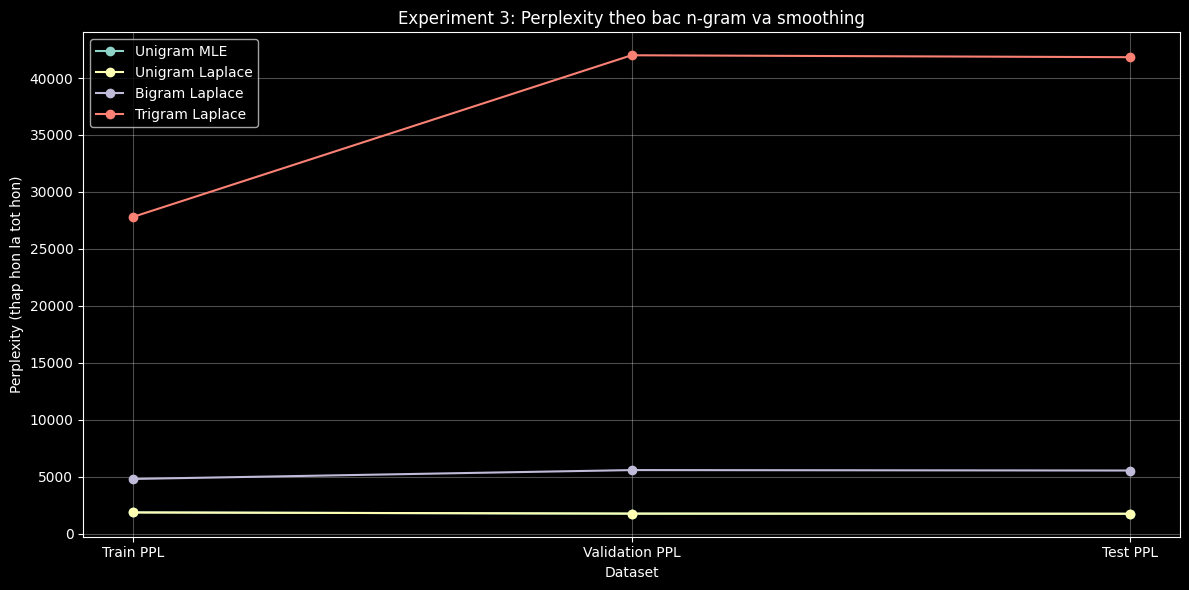

,Model,Unique n-grams,Singleton n-grams,Test - Train PPL
0,Unigram MLE,96506,0,-118.646867
1,Unigram Laplace,96506,0,-116.467553
2,Bigram MLE,2233900,1578117,NaN
3,Bigram Laplace,2233900,1578117,739.976148
4,Trigram MLE,5195243,4507085,NaN
5,Trigram Laplace,5195243,4507085,14017.250562


In [12]:
# Ve perplexity tren ba tap du lieu.
ppl_columns = ['Train PPL', 'Validation PPL', 'Test PPL']
plot_data = experiment_3_results.melt(
    id_vars=['Model', 'Order', 'Smoothing'],
    value_vars=ppl_columns,
    var_name='Dataset',
    value_name='Perplexity',
)

fig, axis = plt.subplots(figsize=(12, 6))
for model_name, group in plot_data.groupby('Model', sort=False):
    finite_group = group[group['Perplexity'].replace(
        [float('inf'), float('-inf')], float('nan')
    ).notna()]
    if not finite_group.empty:
        axis.plot(
            finite_group['Dataset'],
            finite_group['Perplexity'],
            marker='o',
            label=model_name,
        )

axis.set_title('Experiment 3: Perplexity theo bac n-gram va smoothing')
axis.set_xlabel('Dataset')
axis.set_ylabel('Perplexity (thap hon la tot hon)')
axis.grid(True, alpha=0.3)
axis.legend()
plt.tight_layout()
plt.show()

display(
    experiment_3_results[
        ['Model', 'Unique n-grams', 'Singleton n-grams', 'Test - Train PPL']
    ].sort_values('Unique n-grams')
)